<h1><center>NEMREG TEMPLATE</center></h1>

This is a template that can easily be edited to fit the user spesific case. The only thing that is needed to change is the variables as shown under. 

THe document is set up in a way as a instruction manual, all prior steps need to be made to do the next step. All steps are not rewuired, it all depends on the user interest. 

<h2>Step 1: Import all nessesary libraries</h2>

In [5]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import shutil
import subprocess
import platform
from typing import Callable, Optional

import numpy as np
import matplotlib.pyplot as plt

import nemreg as nr
from nemreg.export.latex import latex


<h2>Step 2: Make dataset and plot the data</h2>

In [6]:
# ----------------------------
# Dataset arrays
# ----------------------------

# User defines the raw data here

x = np.linspace(-5, 5, 60)
y = 2.5 * x - 1.0 + np.random.normal(0, 0.7, size=x.size)

# Optional extra features (uncomment if needed)
# x2 =
# x3 =

# Optional measurement errors
yerr = 0.7           # None, scalar, or array
xerr = None          # None, scalar, or array


# ----------------------------
# Dataset metadata
# ----------------------------

dataset_name = "Example dataset"

xlabel = "x"
ylabel = "y"

xunit = ""
yunit = ""


# ----------------------------
# Dataset object creation
# ----------------------------

ds = nr.Dataset(
    x=x,
    y=y,
    yerr=yerr,
    xerr=xerr,
    name=dataset_name,
    xlabel=xlabel,
    ylabel=ylabel,
    xunit=xunit,
    yunit=yunit,
)

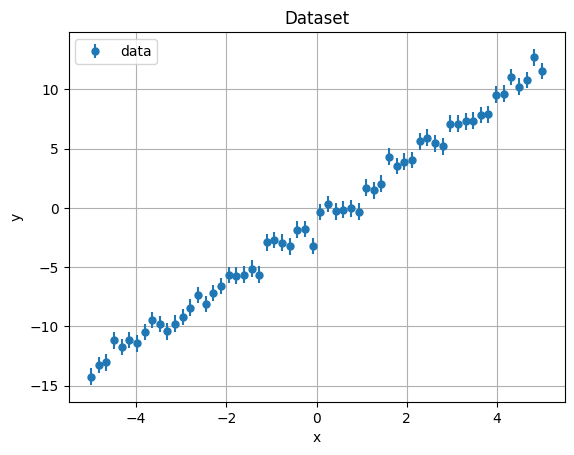

In [7]:
# ============================================================
# DATASET PLOTTING SETTINGS
# ============================================================

# matplotlib axis (None → create automatically)
plot_ax = None

# Plot mode
plot_mode = "data"

# Marker style
marker = "o"

# Marker size
markersize = 5

# Line style (dataset normally uses None)
linestyle = "None"

# Label used in legend
data_label = "data"

# Plot title and axis labels
plot_title = "Dataset"
plot_xlabel = None      # None → use dataset xlabel
plot_ylabel = None      # None → use dataset ylabel

# Grid and legend
grid = True
legend = True

# Blocking behaviour
plot_blocking = True


# ============================================================
# PLOT DATASET
# ============================================================


nr.plot(
    mode=plot_mode,
    dataset=ds,
    ax=plot_ax,

    marker=marker,
    markersize=markersize,
    linestyle=linestyle,
    label=data_label,

    title=plot_title,
    xlabel=plot_xlabel,
    ylabel=plot_ylabel,

    grid=grid,
    legend=legend,
)

plt.show(block=plot_blocking)

<h2>Step 3: Do The Regressional Analysis</h2>

In [8]:
# ----------------------------
# MODEL SELECTION
# ----------------------------

# Choose the model used for regression
model_name = "linear"   # change to other models if available

"""
Other valid models are
"base", "custom", "damped_oscillation", "exponential", "gaussian", "linear", "logarithmic", "logistic", "lorentzian", 
"multivariable_linear", "multivariable_polynomial", "polynomial", "power", "rational", "surface", "sinusoidal", "cosine",
"tangent", "arctan", "arcsin", "arccos"
"""


# ============================================================
# FIT SETTINGS (all parameters exposed)
# ============================================================

# Initial guess for parameters
fit_p0 = None

# Parameter bounds
fit_bounds = (-np.inf, np.inf)

# Maximum function evaluations
fit_maxfev = 100000

# Optimization method
# Options typically: "lm", "trf", "dogbox", or None
fit_method = None

# Whether dataset.yerr should be treated as absolute sigma
fit_absolute_sigma = None


# ============================================================
# RUN THE FIT
# ============================================================

res = nr.fit(
    ds,
    model,
    p0=fit_p0,
    bounds=fit_bounds,
    maxfev=fit_maxfev,
    method=fit_method,
    absolute_sigma=fit_absolute_sigma,
)

NameError: name 'model' is not defined

<h2>Step 4: Plot the Fitted Function</h2>

/Users/nemeth/Programing/DTU_Programming/Test/nemreg/src/nemreg/plotting/plot_result_data.py:80: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x_disp, y, xerr=xerr_disp, yerr=yerr, fmt=data_marker, linestyle="None", **kwargs)


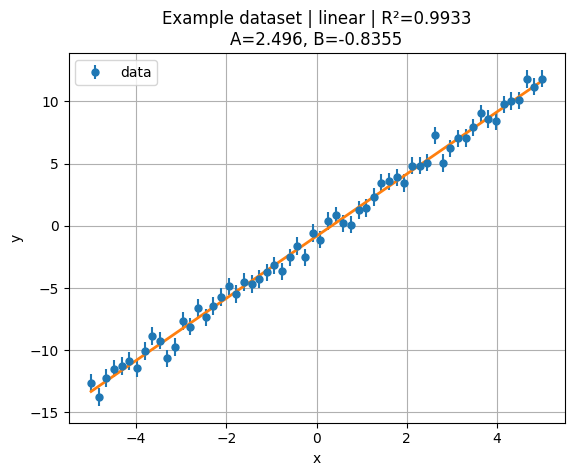

In [ ]:
# ============================================================
# PLOT SETTINGS (safe with your current plot_result_data / plot_data)
# ============================================================

# ----------------------------
# PLOT MODE
# ----------------------------
plot_mode = "result_data"   # "data" | "result_data" | "result" | "multivariable"

# ----------------------------
# AXIS / FIGURE CONTROL
# ----------------------------
plot_ax = None              # None -> create new fig/ax inside plotter
plot_blocking = True        # plt.show(block=...)

# ----------------------------
# WHAT TO SHOW (only used if plot_mode == "result")
# ----------------------------
result_plot_mode = "fit"    # "fit" | "residuals" | "both"
fit_n_grid = 400            # only used if your plot_result supports it

# ----------------------------
# STYLE SETTINGS (dataset)
# ----------------------------
data_marker = "o"
data_markersize = 5
data_label = "data"

# IMPORTANT:
# If your plot_data/plot_result_data uses ax.errorbar(..., linestyle="None", **kwargs),
# then DO NOT pass linestyle in kwargs (it will collide).
# Keep it as a variable if you want, but don't pass it.
data_linestyle = "None"

# ----------------------------
# STYLE SETTINGS (fit / residuals)
# ----------------------------
# These only work if your plot_result_data supports fit_* / resid_* kwargs.
# If it doesn't, leave them here but don't pass them.
fit_linestyle = "-"
fit_linewidth = 2.0
fit_label = "fit"

resid_marker = "o"
resid_markersize = 4
resid_linestyle = "None"
resid_label = "residuals"

# ----------------------------
# TITLES / LABEL OVERRIDES
# ----------------------------
plot_title = None
plot_xlabel = None
plot_ylabel = None

# ----------------------------
# DECORATIONS
# ----------------------------
plot_grid = True
plot_legend = True


# ============================================================
# ACTUAL PLOT CALL
# ============================================================

# NOTE:
# - We do NOT pass `linestyle=data_linestyle` to avoid the error:
#   "Axes.errorbar() got multiple values for keyword argument 'linestyle'"
# - We also do NOT pass fit_* unless plot_result_data explicitly supports them.

fig, ax = nr.plot(
    mode=plot_mode,
    dataset=ds,
    result=res,
    ax=plot_ax,

    # dataset appearance
    marker=data_marker,
    markersize=data_markersize,
    label=data_label,

    # titles (only if your plot_* functions accept these)
    title=plot_title,

    # decorations (must be consumed by plot_result_data/plot_data, NOT forwarded to ax.plot)
    grid=plot_grid,
    legend=plot_legend,
)

plt.show(block=plot_blocking)

<h2>Step 5: Summary - Latex or Text </h2>

>Note if the user want to get the summary in Latex they need to make sure they have the Latex library installed

<h3> Text </h2>

In [ ]:
# ============================================================
# STEP 5: SUMMARY SETTINGS
# ============================================================

# digits used in summary printing
summary_digits = 6

# show expression string
summary_show_expression = True

# show latex string
summary_show_latex = True

# show parameter dictionary
summary_show_params_dict = False

# show stats dictionary
summary_show_stats_dict = False

# show meta dictionary
summary_show_meta_dict = False


# ============================================================
# STEP 5: PRINT SUMMARY
# ============================================================

print("\n====================================================")
print("FIT SUMMARY")
print("====================================================")

print(res.summary(digits=summary_digits))


# ------------------------------------------------------------
# Expression
# ------------------------------------------------------------
if summary_show_expression:

    expr = res.expr_str(digits=summary_digits)

    print("\nExpression:")
    print(f"f(variables) = {expr}")


# ------------------------------------------------------------
# Latex Expression
# ------------------------------------------------------------
if summary_show_latex:

    latex_expr = res.latex_str(digits=summary_digits)

    print("\nLaTeX expression:")
    print(latex_expr)


# ------------------------------------------------------------
# Parameter dictionary
# ------------------------------------------------------------
if summary_show_params_dict:

    print("\nParameters dict:")
    print(res.params_dict())


# ------------------------------------------------------------
# Stats dictionary
# ------------------------------------------------------------
if summary_show_stats_dict:

    print("\nStats:")
    for k, v in res.stats.items():
        print(f"{k}: {v}")


# ------------------------------------------------------------
# Meta dictionary
# ------------------------------------------------------------
if summary_show_meta_dict:

    print("\nMeta:")
    for k, v in res.meta.items():
        print(f"{k}: {v}")


FIT SUMMARY
Model: linear
n=60, p=2, dof=58
  A = 2.49576 ± 0.0307875
  B = -0.835474 ± 0.0903696
R²=0.993302, RMSE=0.601544, χ²=44.3088, χ²_red=0.763944

Expression:
f(variables) = 2.49576*x + -0.835474

LaTeX expression:
2.49576 x + -0.835474


<h2>Latex </h>

In [ ]:
# ----------------------------
# WHICH TEMPLATE
# ----------------------------
latex_template_id = 1                 # 1 -> latex1

# ----------------------------
# OUTPUT PATHS
# ----------------------------
latex_out_dir = Path("out_full_test") # folder to write .tex/.pdf/plots
latex_filename_stem = "report_1"      # report_1.tex, report_1.pdf

# ----------------------------
# PDF COMPILATION
# ----------------------------
latex_run_pdflatex = True             # True -> tries pdflatex if installed

# ----------------------------
# REPORT TEXT
# ----------------------------
latex_title = "Testing title"

# Notes:
# - latex1.py currently uses notes_block_lines to create blank \textit{} lines
# - If you added notes_text support in LatexReportOptions + build_report_tex, expose it here
latex_notes_block_lines = 4

# Optional: only works if you implemented it in LatexReportOptions/build_report_tex
latex_notes_text = ""                 # leave "" to keep blanks in .tex

# ----------------------------
# NUMBER FORMATTING
# ----------------------------
latex_digits = 4

# ----------------------------
# FIGURE / PLOT OUTPUT QUALITY
# ----------------------------
latex_figsize = (6.0, 4.0)            # matplotlib figure size
latex_dpi = 160                       # PNG resolution

# ----------------------------
# FIGURE SCALING IN THE PDF (LATEX)
# ----------------------------
latex_figure_scale_x = 1.0
latex_figure_scale_y = 1.0

# ----------------------------
# OPTIONAL “REAL LIFE MODEL” OVERLAY
# ----------------------------
latex_enable_optional_func = True     # set False to remove overlay
latex_optional_func_label = "textbook model"  # shown in plot legend + caption (when enabled)

def _real_life_model(x):
    """
    Optional overlay model.

    IMPORTANT:
    - For 1D datasets, latex1 will call this with xg = np.linspace(min(x), max(x), ...)
      so your function must accept x as a 1D array and return y as same shape.
    """
    x = np.asarray(x, float)
    return 2.5 * x - 1.0

latex_optional_func = _real_life_model if latex_enable_optional_func else None

# ----------------------------
# OPTIONAL: CUSTOM PLOT LABELS (ONLY IF YOU ADDED THESE FIELDS)
# ----------------------------
# These only work if LatexReportOptions and _plot_data_fit_png read them.
latex_plot_title = None               # None -> latex1 default
latex_plot_xlabel = None              # None -> dataset xlabel
latex_plot_ylabel = None              # None -> dataset ylabel
latex_data_label = "data"
latex_fit_label = "fit"
latex_real_life_model_label = None    # None -> uses latex_optional_func_label

# ============================================================
# RUN EXPORT
# ============================================================

export = latex(
    latex_template_id,
    ds,
    res,
    out_dir=str(latex_out_dir),
    filename_stem=latex_filename_stem,
    run_pdflatex=latex_run_pdflatex,

    # ---- forwarded into LatexReportOptions (must exist in dataclass) ----
    title=latex_title,
    notes_block_lines=latex_notes_block_lines,
    digits=latex_digits,
    figsize=latex_figsize,
    dpi=latex_dpi,
    optional_func=latex_optional_func,
    optional_func_label=latex_optional_func_label,
    figure_scale_x=latex_figure_scale_x,
    figure_scale_y=latex_figure_scale_y,

    # ---- only if you implemented these in LatexReportOptions ----
    # notes_text=latex_notes_text,
    # plot_title=latex_plot_title,
    # plot_xlabel=latex_plot_xlabel,
    # plot_ylabel=latex_plot_ylabel,
    # data_label=latex_data_label,
    # fit_label=latex_fit_label,
    # real_life_model_label=latex_real_life_model_label,
)

# ============================================================
# PRINT PATHS + QUICK OPEN HINT
# ============================================================

print("\n====================================================")
print("LATEX EXPORT DONE")
print("====================================================")
for k, v in export.paths.items():
    print(f"{k}: {v}")

pdf_path = export.paths.get("pdf", None)
tex_path = export.paths.get("tex", None)

if pdf_path:
    print(f"\nPDF should be here:\n  {pdf_path}")
else:
    print("\nNo PDF returned (pdflatex missing or run_pdflatex=False).")

if tex_path:
    print(f"\nTeX should be here:\n  {tex_path}")


LATEX EXPORT DONE
tex: /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.tex
png: /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/plot_data_fit.png
assets: /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test
pdf: /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.pdf

PDF should be here:
  /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.pdf

TeX should be here:
  /Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.tex


/Users/nemeth/Programing/DTU_Programming/Test/nemreg/src/nemreg/plotting/plot_result_data.py:80: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x_disp, y, xerr=xerr_disp, yerr=yerr, fmt=data_marker, linestyle="None", **kwargs)


{'tex': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.tex', 'png': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/plot_data_fit.png', 'assets': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test', 'pdf': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_1.pdf'}


0

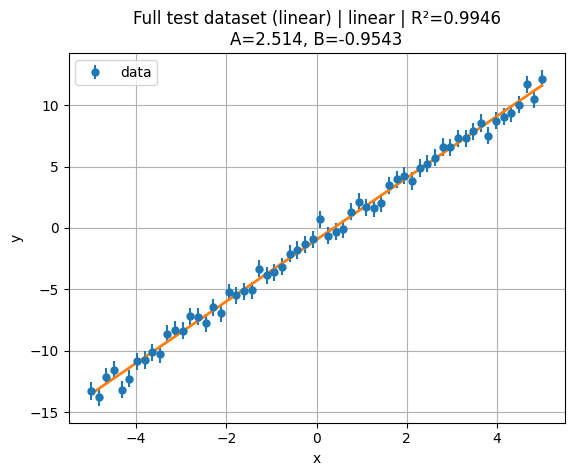

In [ ]:
x=np.linspace(-5,5,60); y=2.5*x-1.0+np.random.default_rng(42).normal(0,0.7,x.size); yerr=0.7; DIG=4; RUN=True; OUT="out_full_test"; STEM="report_1"
ds=nr.Dataset(x=x,y=y,yerr=yerr,xlabel="x",ylabel="y",name="Full test dataset (linear)")
m=nr.models.linear(); res=nr.fit(ds,m,p0=None,bounds=(-np.inf,np.inf),maxfev=100000,method=None,absolute_sigma=True)
nr.plot(mode="result_data",dataset=ds,result=res,grid=True,legend=True,marker="o",markersize=5,label="data")  # <- no linestyle here
real=lambda t: 2.5*np.asarray(t)-1.0
export=latex(1,ds,res,out_dir=OUT,filename_stem=STEM,run_pdflatex=RUN,title="Testing title",digits=DIG,notes_block_lines=4,figsize=(6,4),dpi=180,optional_func=real,optional_func_label="textbook model",figure_scale_x=1.25,figure_scale_y=1.0)
print({k:str(v) for k,v in export.paths.items()})
(__import__("os").system(f"open '{export.paths.get('pdf','')}'") if export.paths.get("pdf") else None)

/Users/nemeth/Programing/DTU_Programming/Test/nemreg/src/nemreg/plotting/plot_result_data.py:80: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x_disp, y, xerr=xerr_disp, yerr=yerr, fmt=data_marker, linestyle="None", **kwargs)


Model: linear
n=80, p=2, dof=78
  A = 2.529 ± 0.01912
  B = -1.106 ± 0.06708
R²=0.9966, RMSE=0.5212, χ²=60.37, χ²_red=0.7739
f(variables) = 2.529*x + -1.106
latex: 2.529 x + -1.106
{'tex': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_demo.tex', 'png': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/plot_data_fit.png', 'assets': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test', 'pdf': '/Users/nemeth/Programing/DTU_Programming/Test/nemreg/out_full_test/report_demo.pdf'}


0

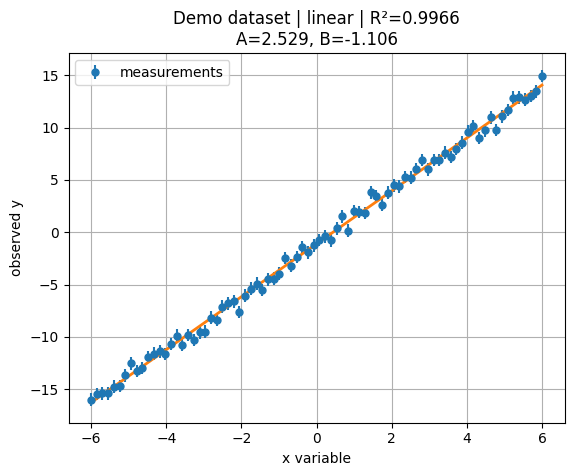

In [12]:
x=np.linspace(-6,6,80); rng=np.random.default_rng(7)
trueA=2.5; trueB=-1.0; sigma=0.6
y=trueA*x+trueB+rng.normal(0,sigma,x.size); yerr=sigma
DIG=4; RUN=True; OUT="out_full_test"; STEM="report_demo"
title="Linear regression demonstration"; notes_text="Synthetic dataset with Gaussian noise, ipsum lorem, ipsum lorem, ipsum lorem, ipsum lorem, ipsum lorem, ipsum lorem, ipsum lorem, ipsum lorem"
figsize=(7,4); dpi=200; sx=1.0; sy=1.0
label_data="measurements"; label_fit="fit"; label_model="true model"
xlabel="x variable"; ylabel="observed y"
ds=nr.Dataset(x=x,y=y,yerr=yerr,xlabel=xlabel,ylabel=ylabel,name="Demo dataset")
m=nr.models.linear()
res=nr.fit(ds,m,p0=None,bounds=(-np.inf,np.inf),maxfev=100000,method=None,absolute_sigma=True)
nr.plot(mode="result_data",dataset=ds,result=res,grid=True,legend=True,marker="o",markersize=5,label=label_data)
expr=res.expr_str(DIG); latex_expr=res.latex_str(DIG)
print(res.summary(digits=DIG))
print("f(variables) =",expr)
print("latex:",latex_expr)
real=lambda t: trueA*np.asarray(t)+trueB
export=latex(
    1, ds, res,
    out_dir=OUT, filename_stem=STEM, run_pdflatex=RUN,
    title=title,
    notes_block_lines=4,
    notes_text=notes_text,
    digits=DIG,
    figsize=figsize, dpi=dpi,
    optional_func=real, optional_func_label=label_model,
    figure_scale_x=sx, figure_scale_y=sy
)
print({k:str(v) for k,v in export.paths.items()})
(__import__("os").system(f"open '{export.paths.get('pdf','')}'") if export.paths.get("pdf") else None)